# IUCAA School on Probability and Statistics for Astronomy
## Day 5 — Maximum Likelihood Estimation

**Datasets used**
- `supernova_data.txt` — Problem 1 (Hubble constant)
- `galaxy_spectrum.txt` — Problem 2 (galaxy redshift)
- `grb_lightcurve.txt` — Problem 3 (GRB X-ray afterglow)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    'figure.figsize'  : (8, 5),
    'font.size'       : 13,
    'axes.labelsize'  : 13,
    'axes.titlesize'  : 14,
    'legend.fontsize' : 11,
    'lines.linewidth' : 1.8,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
})

In [ ]:
!pip -q install gdown

import gdown
from pathlib import Path

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

folder_url = "https://drive.google.com/drive/folders/1YE6xECp4G2HXsel7qI7tMbF8J69BvFTF?usp=drive_link"

gdown.download_folder(
    folder_url,
    output=str(DATA_DIR),
    quiet=False
)

Retrieving folder contents


Processing file 16JndcneDK48DezaBQWhM5FNkamEyQfCh galaxy_spectrum.txt
Processing file 1vPyec19WeBocmR8Vc5ssnKprBSBR1y4I grb_lightcurve.txt
Processing file 1fxdXriwTMJ4AefyWKUd64P1N2df-ReB9 supernova_data.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=16JndcneDK48DezaBQWhM5FNkamEyQfCh
To: /content/data/galaxy_spectrum.txt
100%|██████████| 214k/214k [00:00<00:00, 43.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vPyec19WeBocmR8Vc5ssnKprBSBR1y4I
To: /content/data/grb_lightcurve.txt
100%|██████████| 5.55k/5.55k [00:00<00:00, 8.92MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fxdXriwTMJ4AefyWKUd64P1N2df-ReB9
To: /content/data/supernova_data.txt
100%|██████████| 8.02k/8.02k [00:00<00:00, 17.4MB/s]
Download completed


['/content/data/galaxy_spectrum.txt',
 '/content/data/grb_lightcurve.txt',
 '/content/data/supernova_data.txt']

---
## Problem 1: Estimating the Hubble constant from supernova data

### 1a. Explore the data

In [ ]:
# Load the supernova dataset (columns: z, d_L, sigma_dL)
sn_data = np.loadtxt('/content/data/supernova_data.txt')
print(f'{sn_data.shape[0]} supernovae loaded')
sn_data[:5]

175 supernovae loaded


array([[1.50000000e-02, 6.80300480e+01, 5.05815571e+00],
       [1.50000000e-02, 6.64174493e+01, 6.52679002e+00],
       [1.50000000e-02, 7.51544258e+01, 7.52240933e+00],
       [1.50270428e-02, 6.16649382e+01, 5.05812334e+00],
       [1.51000000e-02, 8.03850077e+01, 7.91022812e+00]])

In [ ]:
z_arr  = sn_data[:, 0]   # redshift
dL_arr = sn_data[:, 1]   # luminosity distance (Mpc)
dL_err = sn_data[:, 2]   # uncertainty in d_L (Mpc)

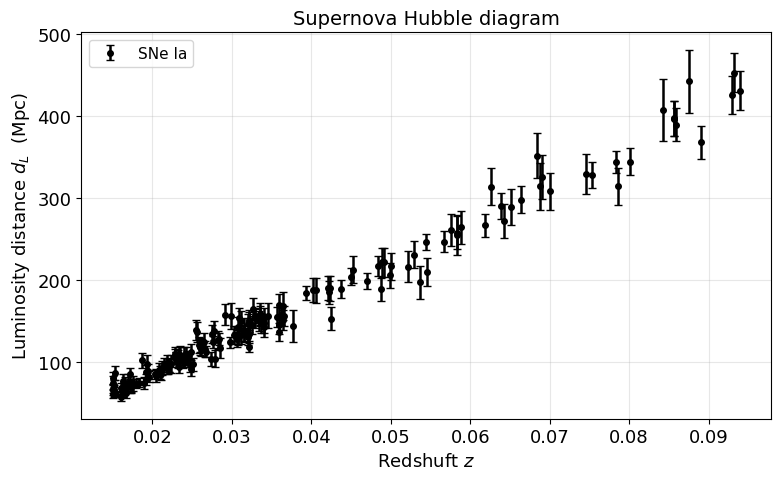

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(z_arr, dL_arr, yerr=dL_err, fmt='o', ms=4, capsize=3, color='k', label='SNe Ia')
ax.set_xlabel('Redshuft $z$')
ax.set_ylabel('Luminosity distance $d_L$  (Mpc)')
ax.set_title('Supernova Hubble diagram')
ax.legend()
plt.tight_layout()

**Derivation: recession velocity from redshift**

The relativistic Doppler formula relates the observed redshift $z$ to the source's
velocity $v = \beta c$:

$$
1 + z = \sqrt{\frac{1+\beta}{1-\beta}}
$$

Squaring both sides and solving for $\beta$:

$$
(1+z)^2 = \frac{1+\beta}{1-\beta}
\implies
(1+z)^2 (1-\beta) = 1+\beta
\implies
(1+z)^2 - 1 = \beta\bigl[(1+z)^2 + 1\bigr]
$$

$$
\therefore\quad
v = c\,\beta = c\,\frac{(1+z)^2 - 1}{(1+z)^2 + 1}
$$

In [ ]:
def recession_velocity(z, c=299792.458):
    """Recession velocity from the relativistic Doppler relation."""
    return c * ((1 + z)**2 - 1) / ((1 + z)**2 + 1)

v_arr = recession_velocity(z_arr)   # km/s

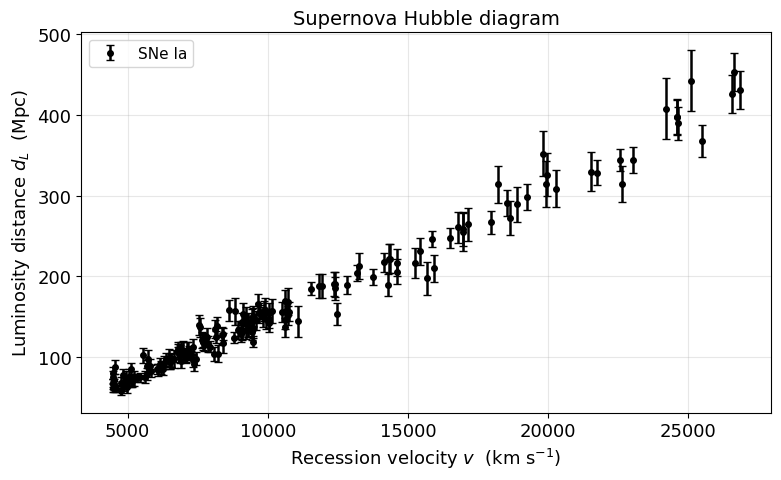

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(v_arr, dL_arr, yerr=dL_err, fmt='o', ms=4, capsize=3, color='k', label='SNe Ia')
ax.set_xlabel('Recession velocity $v$  (km s$^{-1}$)')
ax.set_ylabel('Luminosity distance $d_L$  (Mpc)')
ax.set_title('Supernova Hubble diagram')
ax.legend()
plt.tight_layout()

The luminosity distance increases linearly with recession velocity, consistent with Hubble's law.
The uncertainties are **heteroscedastic** — they grow with $d_L$.

### 1b. Construct the likelihood

**Derivation: Gaussian log-likelihood**

For a single measurement, the Gaussian probability model is

$$
p(d_i \mid H)
= \frac{1}{\sqrt{2\pi\sigma_{d_L,i}^2}}
\exp\!\left[-\frac{(d_i - v_i/H)^2}{2\sigma_{d_L,i}^2}\right]
$$

Assuming the $N$ measurements are independent, the full likelihood is

$$
\mathscr{L}(H) = \prod_{i=1}^{N} p(d_i \mid H)
$$

Taking the natural logarithm and using $\ln(AB) = \ln A + \ln B$:

$$
\ln\mathscr{L}(H)
= \sum_{i=1}^{N} \ln p(d_i \mid H)
= \sum_{i=1}^{N} \left[
-\tfrac{1}{2}\ln(2\pi\sigma_{d_L,i}^2)
-\frac{(d_i - v_i/H)^2}{2\sigma_{d_L,i}^2}
\right]
$$

$$
\boxed{
\ln\mathscr{L}(H) = -\frac{1}{2}\sum_{i=1}^{N}\left[
\frac{(d_i - v_i/H)^2}{\sigma_{d_L,i}^2}
+ \ln(2\pi\sigma_{d_L,i}^2)
\right]
}
$$

Because $\ln$ is a strictly monotone increasing function, maximising
$\ln\mathscr{L}$ always gives the same parameter values as maximising $\mathscr{L}$.
Equivalently, we can minimise the **negative** log-likelihood.

In [ ]:
def log_likelihood_hubble(H):
    """Gaussian log-likelihood for the Hubble constant."""
    residuals = dL_arr - v_arr / H
    return -0.5 * np.sum(residuals**2 / dL_err**2 + np.log(2 * np.pi * dL_err**2))

In [ ]:
log_likelihood_hubble(70.0)

np.float64(-698.6161585114605)

### 1c. Maximum likelihood estimation

In [ ]:
# ── Grid evaluation ──────────────────────────────────────
H_grid    = np.linspace(50, 100, 500)
logL_grid = np.array([log_likelihood_hubble(H) for H in H_grid])

H_ml_grid = H_grid[np.argmax(logL_grid)]
print(f'Grid MLE:  H₀ = {H_ml_grid:.2f} km/s/Mpc')

Grid MLE:  H₀ = 67.13 km/s/Mpc


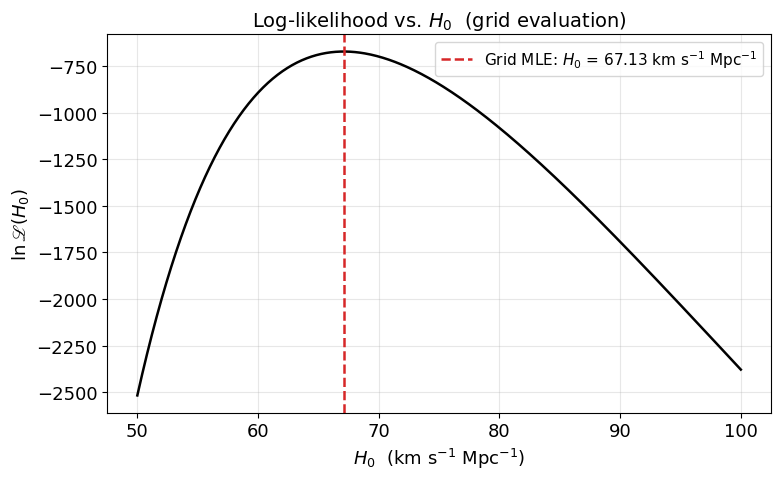

In [ ]:
fig, ax = plt.subplots()
ax.plot(H_grid, logL_grid, color='k')
ax.axvline(H_ml_grid, color='tab:red', ls='--',
           label=f'Grid MLE: $H_0$ = {H_ml_grid:.2f} km s$^{{-1}}$ Mpc$^{{-1}}$')
ax.set_xlabel('$H_0$  (km s$^{-1}$ Mpc$^{-1}$)')
ax.set_ylabel(r'$\ln\mathscr{L}(H_0)$')
ax.set_title('Log-likelihood vs. $H_0$  (grid evaluation)')
ax.legend()
plt.tight_layout()

In [ ]:
# ── Numerical optimization ───────────────────────────────
def neg_log_likelihood_hubble(H):
    return -log_likelihood_hubble(H)

result_opt = minimize(neg_log_likelihood_hubble, x0=[70.0])
H_ml_opt   = result_opt.x[0]
print(f'Optimized MLE: H₀ = {H_ml_opt:.4f} km/s/Mpc  (converged: {result_opt.success})')

Optimized MLE: H₀ = 67.1033 km/s/Mpc  (converged: True)


**Derivation: analytical MLE for $H_0$**

The normalization terms $\ln(2\pi\sigma_{d_L,i}^2)$ are independent of $H$,
so setting $\dfrac{d}{dH}\ln\mathscr{L} = 0$ reduces to

$$
\frac{d}{dH}\left[
-\frac{1}{2}\sum_i \frac{(d_i - v_i/H)^2}{\sigma_{d_L,i}^2}
\right] = 0
$$

Differentiating (using the chain rule with $\partial(d_i - v_i/H)/\partial H = v_i/H^2$):

$$
\sum_i \frac{(d_i - v_i/H)}{\sigma_{d_L,i}^2}\cdot\frac{v_i}{H^2} = 0
\implies
\sum_i \frac{v_i\,d_i}{\sigma_{d_L,i}^2}
= \frac{1}{H}\sum_i \frac{v_i^2}{\sigma_{d_L,i}^2}
$$

Solving for $H$:

$$
\boxed{
H_{\mathrm{ML}}
= \frac{\displaystyle\sum_i \dfrac{v_i^2}{\sigma_{d_L,i}^2}}
         {\displaystyle\sum_i \dfrac{v_i\,d_i}{\sigma_{d_L,i}^2}}
}
$$

This is a **weighted least-squares** estimator: each data point contributes with
weight $1/\sigma_{d_L,i}^2$, so precise measurements have more influence on the fit.

In [ ]:
# ── Analytical solution ──────────────────────────────────
def analytical_mle_hubble(v, dL, sigma_dL):
    w = 1.0 / sigma_dL**2
    return np.sum(w * v**2) / np.sum(w * v * dL)

H_ml_analytical = analytical_mle_hubble(v_arr, dL_arr, dL_err)
print(f'Analytical MLE:  H₀ = {H_ml_analytical:.4f} km/s/Mpc')

# Effect of assuming equal uncertainties
sigma_equal = np.full_like(dL_err, np.mean(dL_err))
H_ml_equal  = analytical_mle_hubble(v_arr, dL_arr, sigma_equal)
print(f'Equal-σ MLE:     H₀ = {H_ml_equal:.4f} km/s/Mpc')

Analytical MLE:  H₀ = 67.1033 km/s/Mpc
Equal-σ MLE:     H₀ = 65.1276 km/s/Mpc


### 1d. Plot the best-fit models

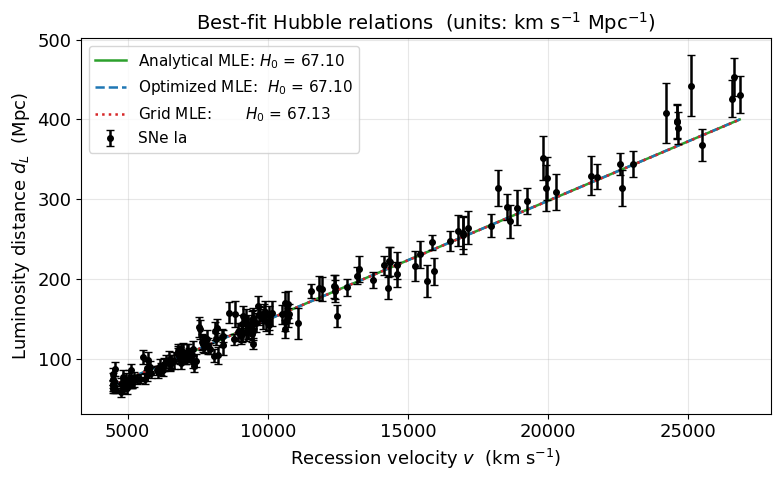

In [ ]:
v_model = np.linspace(v_arr.min(), v_arr.max(), 300)

fig, ax = plt.subplots()
ax.errorbar(v_arr, dL_arr, yerr=dL_err, fmt='o', ms=4, capsize=3,
            color='k', label='SNe Ia', zorder=5)
ax.plot(v_model, v_model / H_ml_analytical, color='tab:green',
        label=f'Analytical MLE: $H_0$ = {H_ml_analytical:.2f}')
ax.plot(v_model, v_model / H_ml_opt, color='tab:blue', ls='--',
        label=f'Optimized MLE:  $H_0$ = {H_ml_opt:.2f}')
ax.plot(v_model, v_model / H_ml_grid, color='tab:red', ls=':',
        label=f'Grid MLE:       $H_0$ = {H_ml_grid:.2f}')
ax.set_xlabel('Recession velocity $v$  (km s$^{-1}$)')
ax.set_ylabel('Luminosity distance $d_L$  (Mpc)')
ax.set_title('Best-fit Hubble relations  (units: km s$^{-1}$ Mpc$^{-1}$)')
ax.legend()
plt.tight_layout()

### 1e. MLE versus ordinary least squares

Gaussian MLE minimises the **weighted** residual sum
$\chi^2 = \sum_i (d_i - v_i/H)^2 / \sigma_i^2$,
giving more influence to precise measurements.
Unweighted OLS minimises $\sum_i (d_i - v_i/H)^2$, treating all points equally.

In [ ]:
def unweighted_chi2(H):
    return np.sum((dL_arr - v_arr / H)**2)

result_ols = minimize(unweighted_chi2, x0=[70.0])
H_ols      = result_ols.x[0]
print(f'Unweighted OLS:    H₀ = {H_ols:.4f} km/s/Mpc')
print(f'Gaussian MLE:      H₀ = {H_ml_analytical:.4f} km/s/Mpc')

Unweighted OLS:    H₀ = 65.1276 km/s/Mpc
Gaussian MLE:      H₀ = 67.1033 km/s/Mpc


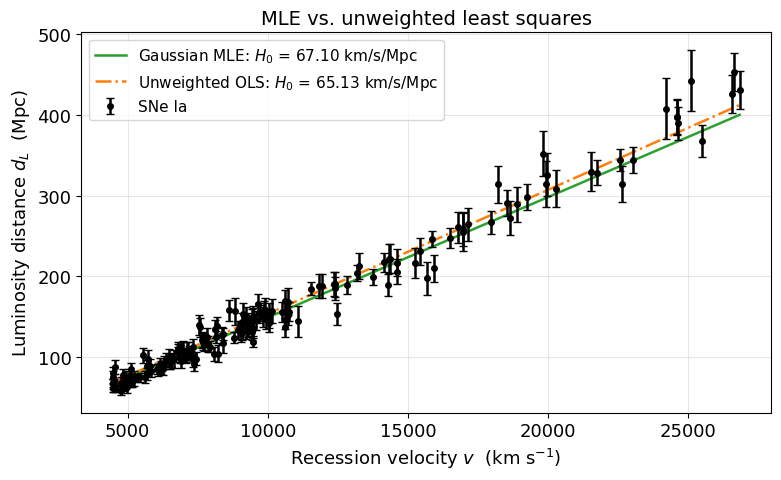

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(v_arr, dL_arr, yerr=dL_err, fmt='o', ms=4, capsize=3,
            color='k', label='SNe Ia', zorder=5)
ax.plot(v_model, v_model / H_ml_analytical, color='tab:green',
        label=f'Gaussian MLE: $H_0$ = {H_ml_analytical:.2f} km/s/Mpc')
ax.plot(v_model, v_model / H_ols, color='tab:orange', ls='-.',
        label=f'Unweighted OLS: $H_0$ = {H_ols:.2f} km/s/Mpc')
ax.set_xlabel('Recession velocity $v$  (km s$^{-1}$)')
ax.set_ylabel('Luminosity distance $d_L$  (Mpc)')
ax.set_title('MLE vs. unweighted least squares')
ax.legend()
plt.tight_layout()

---
## Problem 2: Redshift from a galaxy spectrum

### 2a. Load and inspect the spectrum

In [ ]:
# Load the spectrum (columns: flux, ivar, log10_lambda)
spectrum = np.loadtxt('/content/data/galaxy_spectrum.txt')
print(f'{spectrum.shape[0]} spectral pixels loaded')
spectrum[:5]

3838 spectral pixels loaded


array([[13.37325668,  0.07778049,  3.57920003],
       [16.94845581,  0.0735737 ,  3.57940006],
       [16.64720345,  0.07006555,  3.57949996],
       [16.98689651,  0.08099488,  3.5796001 ],
       [ 9.71174622,  0.09432353,  3.57969999]])

In [ ]:
flux      = spectrum[:, 0]            # flux (arbitrary units)
ivar      = spectrum[:, 1]            # inverse variance
log10_lam = spectrum[:, 2]            # log10(wavelength / Angstrom)

lam     = 10**log10_lam              # wavelength (Angstrom)
sigma_f = 1.0 / np.sqrt(ivar)        # flux uncertainty

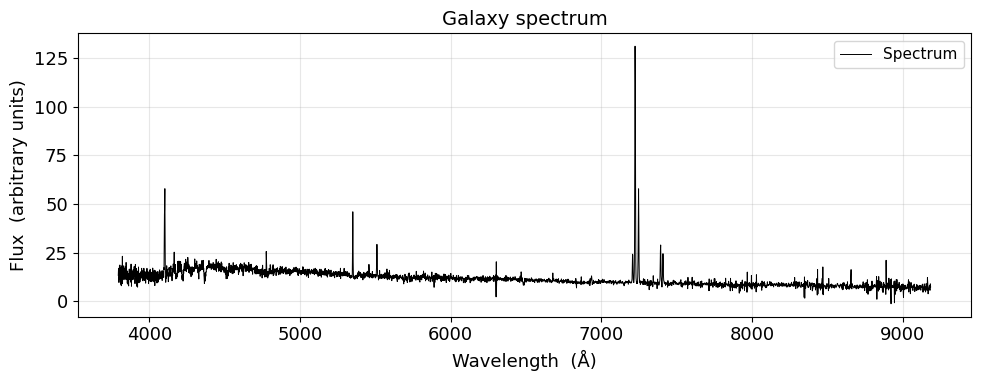

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lam, flux, lw=0.7, color='k', label='Spectrum')
ax.set_xlabel('Wavelength  (Å)')
ax.set_ylabel('Flux  (arbitrary units)')
ax.set_title('Galaxy spectrum')
ax.legend()
plt.tight_layout()

In [ ]:
# Select the H-alpha fitting window
lam_lo, lam_hi = 7210, 7240

mask      = (lam > lam_lo) & (lam < lam_hi)
lam_fit   = lam[mask]
flux_fit  = flux[mask]
sigma_fit = sigma_f[mask]

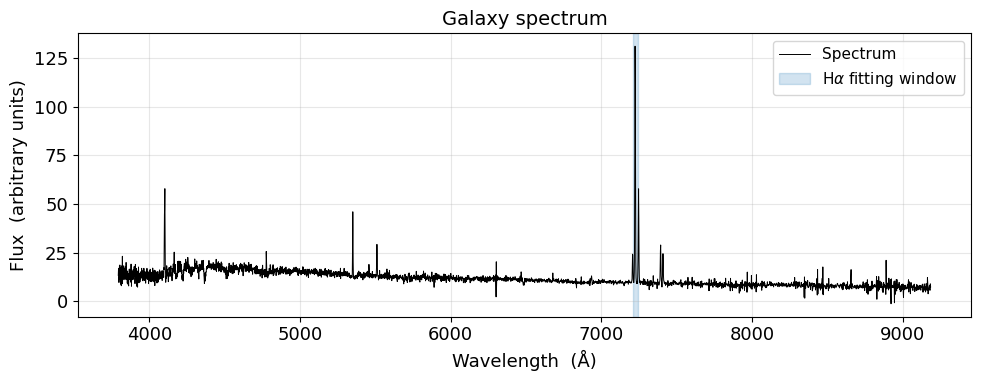

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lam, flux, lw=0.7, color='k', label='Spectrum')
ax.axvspan(lam_lo, lam_hi, alpha=0.2, color='tab:blue', label='H$\\alpha$ fitting window')
ax.set_xlabel('Wavelength  (Å)')
ax.set_ylabel('Flux  (arbitrary units)')
ax.set_title('Galaxy spectrum')
ax.legend()
plt.tight_layout()

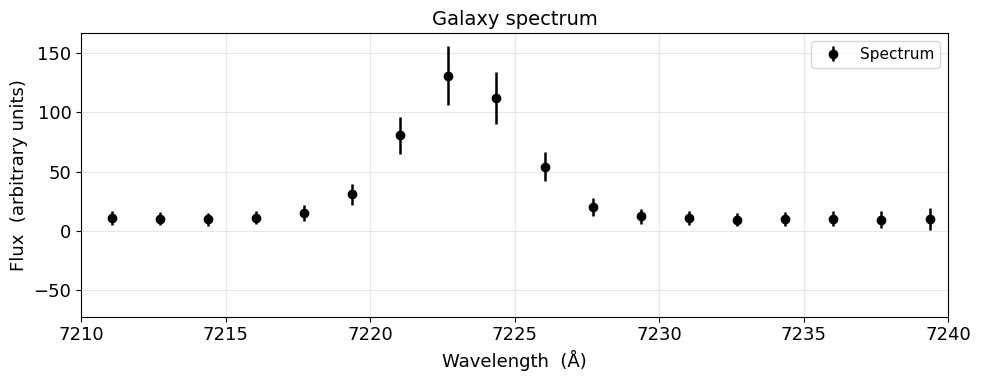

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(lam, flux, lw=0.7, color='k', label='Spectrum')
ax.errorbar(lam, flux,yerr=10*sigma_f,fmt='o',color='k', label='Spectrum')
ax.set_xlabel('Wavelength  (Å)')
ax.set_ylabel('Flux  (arbitrary units)')
ax.set_title('Galaxy spectrum')
ax.set_xlim(lam_lo, lam_hi)
ax.legend()
plt.tight_layout()

### 2b. Model the H$\alpha$ emission line

We use a Gaussian emission line on a constant continuum:

$$
f(\lambda) = C + A\exp\!\left[-\frac{(\lambda - \lambda_0)^2}{2\sigma_\lambda^2}\right]
$$

with parameters $\theta = (C,\, A,\, \lambda_0,\, \sigma_\lambda)$.

In [ ]:
def gaussian_line_model(lam, C, A, lam0, sigma_lam):
    """Gaussian emission line on a flat continuum."""
    return C + A * np.exp(-0.5 * ((lam - lam0) / sigma_lam)**2)

### 2c. Construct the Gaussian likelihood

Same structure as Problem 1, but the model now has four free parameters:

$$
\ln\mathscr{L}(\theta) = -\frac{1}{2}\sum_i\left[
\frac{(f_i - f_{\mathrm{model},i})^2}{\sigma_{f,i}^2} + \ln(2\pi\sigma_{f,i}^2)
\right]
$$

In [ ]:
def log_likelihood_spectrum(params):
    """Gaussian log-likelihood for the spectral line fit."""
    C, A, lam0, sigma_lam = params
    model = gaussian_line_model(lam_fit, C, A, lam0, sigma_lam)
    return -0.5 * np.sum((flux_fit - model)**2 / sigma_fit**2
                         + np.log(2 * np.pi * sigma_fit**2))

def neg_log_likelihood_spectrum(params):
    return -log_likelihood_spectrum(params)

### 2d. Maximum likelihood fitting with `scipy.optimize`

In [ ]:
# Initial guesses from the data in the fitting window
C0      = np.median(flux_fit)
A0      = np.max(flux_fit) - C0
lam0_0  = lam_fit[np.argmax(flux_fit)]
sigma0  = 2.0

x0     = [C0, A0, lam0_0, sigma0]
bounds = [(0, None), (0, None), (lam_lo, lam_hi), (0.1, 50)]

result_spectrum = minimize(neg_log_likelihood_spectrum, x0=x0, bounds=bounds)
print(f'Optimizer converged: {result_spectrum.success}')

Optimizer converged: True


In [ ]:
C_ML, A_ML, lam0_ML, sigma_lam_ML = result_spectrum.x

print(f'C        = {C_ML:.4f}        (continuum level)')
print(f'A        = {A_ML:.4f}        (line amplitude)')
print(f'λ₀       = {lam0_ML:.4f} Å   (line centre)')
print(f'σ_λ     = {sigma_lam_ML:.4f} Å   (line width)')

C        = 10.2051        (continuum level)
A        = 122.1759        (line amplitude)
λ₀       = 7223.1547 Å   (line centre)
σ_λ     = 2.0241 Å   (line width)


### 2e. Plot the maximum-likelihood spectral fit

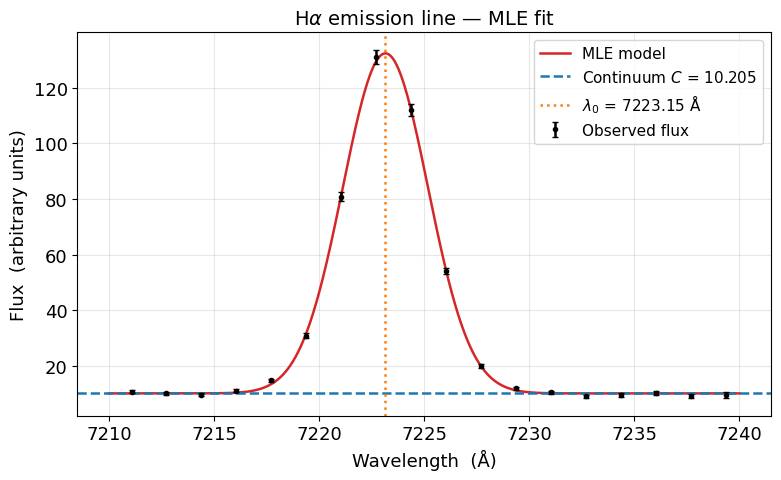

In [ ]:
lam_smooth = np.linspace(lam_lo, lam_hi, 1000)

fig, ax = plt.subplots()
ax.errorbar(lam_fit, flux_fit, yerr=sigma_fit, fmt='.', color='k',
            capsize=2, label='Observed flux', zorder=3)
ax.plot(lam_smooth, gaussian_line_model(lam_smooth, *result_spectrum.x),
        color='tab:red', label='MLE model')
ax.axhline(C_ML, color='tab:blue', ls='--',
           label=f'Continuum $C$ = {C_ML:.3f}')
ax.axvline(lam0_ML, color='tab:orange', ls=':',
           label=f'$\\lambda_0$ = {lam0_ML:.2f} Å')
ax.set_xlabel('Wavelength  (Å)')
ax.set_ylabel('Flux  (arbitrary units)')
ax.set_title('H$\\alpha$ emission line — MLE fit')
ax.legend()
plt.tight_layout()

### 2f. Convert the fitted line centre into redshift

$$
z_{\mathrm{ML}} = \frac{\lambda_{0,\mathrm{ML}}}{\lambda_{\mathrm{H\alpha}}} - 1
$$

In [ ]:
LAM_HALPHA = 6564.6   # H-alpha rest wavelength in vacuum (Angstrom)

z_ML = lam0_ML / LAM_HALPHA - 1
print(f'Observed line centre:  λ₀  = {lam0_ML:.4f} Å')
print(f'ML redshift:           z   = {z_ML:.4f}')

Observed line centre:  λ₀  = 7223.1547 Å
ML redshift:           z   = 0.1003


### 2g. Likelihood around the best fit

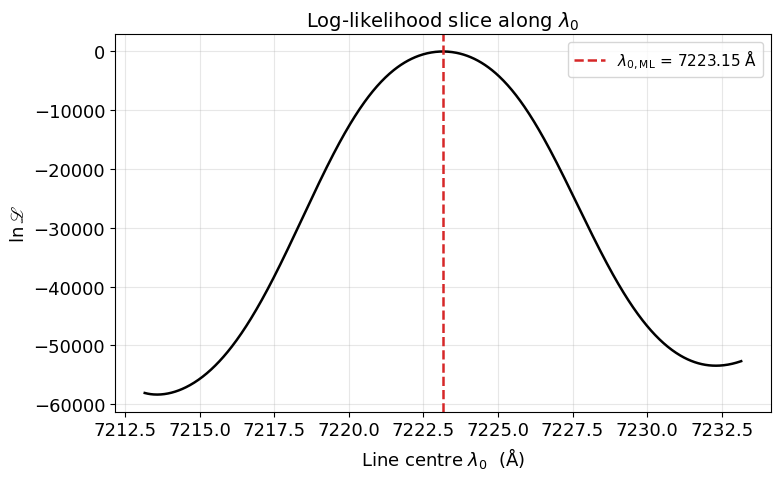

In [ ]:
lam0_grid  = np.linspace(lam0_ML - 10, lam0_ML + 10, 1000)
logL_slice = np.array(
    [log_likelihood_spectrum([C_ML, A_ML, l0, sigma_lam_ML]) for l0 in lam0_grid]
)

fig, ax = plt.subplots()
ax.plot(lam0_grid, logL_slice, color='k')
ax.axvline(lam0_ML, color='tab:red', ls='--',
           label=f'$\\lambda_{{0,\\mathrm{{ML}}}}$ = {lam0_ML:.2f} Å')
ax.set_xlabel('Line centre $\\lambda_0$  (Å)')
ax.set_ylabel(r'$\ln\mathscr{L}$')
ax.set_title('Log-likelihood slice along $\\lambda_0$')
ax.legend()
plt.tight_layout()